In [7]:
import sys, os, torch, time, pickle
# sys.path.append(os.path.abspath('..'))

from Main import hyperparam_config
from Model import TCN
import numpy as np
from torch.utils.data import Dataset, Subset, DataLoader
from itertools import chain
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

class OnlineAdaptator:
    def __init__(self, model_dir, model_name, tcn_frozen_state, learning_rate=5e-6):
        self.model_dir = model_dir
        self.model_name = model_name
        # Device configuration
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.inclinations_all = ['RD_10deg', 'RD_8p75deg', 'RD_7p5deg', 'RD_6p25deg', 'RD_5deg', 'RD_3p75deg', 'RD_2p5deg', 'RD_1p25deg', 'LG',
                    'RA_1p25deg', 'RA_2p5deg', 'RA_3p75deg', 'RA_5deg', 'RA_6p25deg', 'RA_7p5deg', 'RA_8p75deg', 'RA_10deg']
        self.speeds_all = ['0p2mps', '0p25mps', '0p3mps', '0p35mps', '0p4mps', '0p45mps', '0p5mps', '0p55mps', '0p6mps', '0p65mps', '0p7mps', '0p75mps', 
                    '0p8mps', '0p85mps', '0p9mps', '0p95mps', '1p0mps', '1p05mps', '1p1mps', '1p15mps', '1p2mps', '1p25mps', '1p3mps', '1p35mps', '1p4mps']
        self.bin_state = {inc: {spd: 0 for spd in self.speeds_all} for inc in self.inclinations_all}
        self.st_replay_buffer = {inc: {spd: {gc: None for gc in range(2)} for spd in self.speeds_all} for inc in self.inclinations_all}

        self.model_L = TCN(hyperparam_config).to(self.device)
        self.model_R = TCN(hyperparam_config).to(self.device)
        self.model_L.load_state_dict(torch.load(os.path.join(self.model_dir, self.model_name), map_location=self.device))
        self.model_R.load_state_dict(torch.load(os.path.join(self.model_dir, self.model_name), map_location=self.device))

        # Load mean and std for normalization
        self.label_mean = np.load(os.path.join(self.model_dir, 'label_mean.npy'))
        self.label_std = np.load(os.path.join(self.model_dir, 'label_std.npy'))
        self.label_mean_tensor = torch.tensor(self.label_mean, device=self.device)
        self.label_std_tensor = torch.tensor(self.label_std, device=self.device)

        # Freeze all parameters first
        for param in self.model_L.parameters():
            param.requires_grad = False
        for param in self.model_R.parameters():
            param.requires_grad = False

        # Then, unfreeze only the parameters of the final linear layer
        for param in self.model_L.linear.parameters():
            param.requires_grad = True
        for param in self.model_R.linear.parameters():
            param.requires_grad = True

        # Then, unfreeze only the parameters of the final linear layer
        if tcn_frozen_state == 'tcn_unfrozen':
            for param in self.model_L.tcn.parameters():
                param.requires_grad = True
            for param in self.model_R.tcn.parameters():
                param.requires_grad = True

        # Define separate optimizers for each model
                # Define separate optimizers for each model
        self.optimizer_L = torch.optim.Adam(
            chain(self.model_L.tcn.parameters(), self.model_L.linear.parameters()),
            lr=learning_rate,
            weight_decay=1e-5
        )
        self.optimizer_R = torch.optim.Adam(
            chain(self.model_R.tcn.parameters(), self.model_R.linear.parameters()),
            lr=learning_rate,
            weight_decay=1e-5
        )
        self.criterion = torch.nn.MSELoss()

        self.model_L.train()
        self.model_R.train()

    def fine_tune_linear_layer(self, side, incline_course, speed_course, input, num_epochs, batch_size, gait_cycle_index=None, num_gait_cycles=None):

        print(f"{side} side fine-tuning")
        # Create a sample dataset
        Data = LoadData(self, incline_course, speed_course, input, gait_cycle_index=gait_cycle_index, num_gait_cycles=num_gait_cycles)

        # If there are no samples, return the current weights and biases
        if len(Data) == 0:
            print(f"Zero gait cycle got from the {side} side. Skipping fine-tuning.")
            # Get the weights and biases from the updated linear layer
            linear_weights = self.model_L.linear.weight.data.clone()
            linear_biases = self.model_L.linear.bias.data.clone()

            linear_weights_np = linear_weights.cpu().numpy().T
            linear_biases_np = linear_biases.cpu().numpy().T

            return linear_weights_np, linear_biases_np

        # Get the indices for training
        train_indices = list(range(len(Data) - hyperparam_config['window_size'] + 1))
        np.random.shuffle(train_indices)

        # Make the subset for training
        subset = Subset(Data, train_indices)

        # On Jetson, num_workers should be low (0, 1, or 2) to avoid CPU contention.
        # persistent_workers=True avoids worker recreation overhead between epochs.
        train_loader = DataLoader(
            dataset=subset,
            batch_size=batch_size,
            num_workers=2,  # Use a small number for Jetson
            shuffle=True,
            pin_memory=True,
            persistent_workers=True
        )

        time_ = time.time()

        # Train the model
        for epoch in range(num_epochs):
            # internal sampler will re-shuffle the data every epoch automatically
            for i, (input, label) in enumerate(train_loader):                    
                input = input.to(self.device, non_blocking=True)
                label = label.to(self.device, non_blocking=True)
                if side == 'R':
                    self.optimizer_R.zero_grad()
                    logits = self.model_R(input)
                else:
                    self.optimizer_L.zero_grad()
                    logits = self.model_L(input)
                loss = self.criterion(logits, label)
                loss.backward()
                if side == 'R':
                    self.optimizer_R.step()
                else:
                    self.optimizer_L.step()

        print(f"Time spent for backprop: {time.time() - time_}")

        # print("TCN block 0, layer 0 weights:")
        # print(self.model_R.tcn.network[0].network[0].weight.data)
        # print("Linear layer weights:")
        # print(self.model_R.linear.weight.data)

        torch.cuda.empty_cache()

        # Get the weights and biases from the updated linear layer
        if side == 'R':
            linear_weights = self.model_R.linear.weight.data.clone()
            linear_biases = self.model_R.linear.bias.data.clone()
        else: # side == 'L'
            linear_weights = self.model_L.linear.weight.data.clone()
            linear_biases = self.model_L.linear.bias.data.clone()

        linear_weights_np = linear_weights.cpu().numpy().T
        linear_biases_np = linear_biases.cpu().numpy().T

        # print(f"Linear layer weights shape: {linear_weights_np.shape}, biases shape: {linear_biases_np.shape}")

        return linear_weights_np, linear_biases_np

class LoadData(Dataset):
    def __init__(self, adaptator, incline_course, speed_course, input_data, gait_cycle_index=None, num_gait_cycles=None):
        self.input = input_data
        self.window_size = hyperparam_config['window_size']
        self.gait_cycle_index = gait_cycle_index
        self.adaptator = adaptator
        self.incline_course = incline_course
        self.speed_course = speed_course

        # Extract features
        self.peak_indices, _ = find_peaks(-self.input[:, 6], height= None, distance=20, prominence=10)

        # Use only the data between the first and last peaks
        # self.input = self.input[peak_indices[0]:peak_indices[-1], :]
        self.peak_indices = np.insert(self.peak_indices, 0,0)
        self.peak_indices = np.insert(self.peak_indices, len(self.peak_indices), len(self.input))
        print(f"Number of gait cycles: {len(self.peak_indices) - 1}")
        # print(self.peak_indices)

        # TODO: Delete this when running on Jetson
        if gait_cycle_index is not None:
            self.gc = []
            for cycle in range(num_gait_cycles):
                self.gc.append(self.input[self.peak_indices[gait_cycle_index-1+cycle]:self.peak_indices[gait_cycle_index+cycle], :])
            self.input = self.input[self.peak_indices[gait_cycle_index-1]:self.peak_indices[gait_cycle_index-1 + num_gait_cycles], :]
            print(f"Gait cycles used: {num_gait_cycles} from the {gait_cycle_index} th gait cycle")

        # Calculate record time based on the length of the input data
        self.label = self.gait_cycle_generator(self.peak_indices)

        # TODO: Delete this when running on Jetson
        if gait_cycle_index is not None:
            self.label = self.label[self.peak_indices[gait_cycle_index-1]:self.peak_indices[gait_cycle_index-1 + num_gait_cycles], :]

        print('input shape:', self.input.shape)
        print('label shape:', self.label.shape)

        self.load_replay_buffer('/home/metamobility5/Changseob/proj-online_adaptation_GPE/replay_buffer/avg_input_gait_cycles.pkl')

        print('input shape (including replay buffer):', self.input.shape)
        print('label shape (including replay buffer):', self.label.shape)

        # load mean and std for normalization
        input_mean = np.load(os.path.join(model_dir, 'input_mean.npy'))
        input_std = np.load(os.path.join(model_dir, 'input_std.npy'))
        label_mean = np.load(os.path.join(model_dir, 'label_mean.npy'))
        label_std = np.load(os.path.join(model_dir, 'label_std.npy'))
                    
        # Normalize the input features
        self.input = (self.input - input_mean) / input_std
        self.label = (self.label - label_mean) / label_std

    def gait_cycle_generator(self, peak_indices, num_cycles=None):
            gc_angle_list = []
            gc_polar_x_list = []
            gc_polar_y_list = []

            if num_cycles is None:
                num_cycles = len(peak_indices) - 1
            for i in range(num_cycles):
                start = peak_indices[i]
                end = peak_indices[i + 1]

                for j in range(start, end):
                    gc_polar_angle = (j - start) / (end - start) * 2 * np.pi
                    gc_angle_list.append(gc_polar_angle)
                    gc_polar_x_list.append(np.cos(gc_polar_angle))
                    gc_polar_y_list.append(np.sin(gc_polar_angle))

            return np.column_stack((gc_polar_x_list, gc_polar_y_list))

    def load_replay_buffer(self, ab_replay_buffer_file):
        with open(ab_replay_buffer_file, 'rb') as file:
            self.ab_replay_buffer = pickle.load(file)

        # For target task
        self.adaptator.st_replay_buffer[self.incline_course][self.speed_course] = self.gc

        # Interpolate tasks!!
        if self.adaptator.bin_state[self.incline_course][self.speed_course] != 1:
            self.adjacent_task_personalization(self.incline_course, self.speed_course, 7)

        self.adaptator.bin_state[self.incline_course][self.speed_course] = 1

        for inclination in self.adaptator.inclinations_all:
            for speed in self.adaptator.speeds_all:
                # For target task
                if (speed == self.speed_course) and (inclination == self.incline_course):
                    continue

                # For non-target tasks
                else:
                    # when it's not in the bin at all - continue
                    if self.adaptator.bin_state[inclination][speed] == 0:
                        continue
                    # when the target task is already in the bin - experience replay
                    elif self.adaptator.bin_state[inclination][speed] == 1: 
                        for i in range(2):
                            self.input = np.vstack((self.input, self.adaptator.st_replay_buffer[inclination][speed][i]))
                            self.label = np.vstack((self.label, self.gait_cycle_generator([0, self.adaptator.st_replay_buffer[inclination][speed][i].shape[0]])))
                    elif (self.adaptator.bin_state[inclination][speed] < 1) and (self.adaptator.bin_state[inclination][speed] > 0):
                        for i in range(2):
                            self.input = np.vstack((self.input, self.adaptator.st_replay_buffer[inclination][speed][i]))
                            self.label = np.vstack((self.label, self.gait_cycle_generator([0, self.adaptator.st_replay_buffer[inclination][speed][i].shape[0]])))


    def upsampling(self, data, target_length):
        """
        Upsample a 1D numpy array to the desired target length using linear interpolation.
        """
        original_length = len(data)
        original_indices = np.linspace(0, original_length - 1, original_length)
        new_indices = np.linspace(0, original_length - 1, target_length)

        return np.interp(new_indices, original_indices, data)

    def upsampling_2d(self, data, target_length):
        """
        Upsample a 2D numpy array to the desired target length using linear interpolation.
        data: numpy array of shape (n_features, n_samples)
        target_length: desired length of each segment after upsampling
        """
        upsampled_data = np.zeros((data.shape[0], target_length))
        for i in range(data.shape[0]):
            upsampled_data[i, :] = self.upsampling(data[i, :], target_length)

        return upsampled_data  # (target_length, n_features)

    def interpolate_two_cycles(self, cycle1, cycle2, weight):
        interpolated_len = cycle1.shape[1]*weight + cycle2.shape[1]*(1-weight)
        cycle1_upsampled = self.upsampling_2d(cycle1, int(interpolated_len))
        cycle2_upsampled = self.upsampling_2d(cycle2, int(interpolated_len))
        interpolated_cycle = cycle1_upsampled * weight + cycle2_upsampled * (1 - weight)
        return interpolated_cycle

    def adjacent_task_personalization(self, current_inclination, current_speed, spread_distance):
        inclination_idx = self.adaptator.inclinations_all.index(current_inclination)
        speed_idx = self.adaptator.speeds_all.index(current_speed)

        for inclination in self.adaptator.inclinations_all:
            for speed in self.adaptator.speeds_all:
                for i in range(2): # iterate through 2 gc

                    if (inclination == current_inclination) and (speed == current_speed): continue # skip if the interpolation target is the current task
                    if (self.ab_replay_buffer[inclination][speed][i] is None): continue # only if ab buffer is available
                    if (self.adaptator.bin_state[inclination][speed] == 1): continue # only if bin is not filled-up yet

                    # Calculate the distance between the current task and the target task (in the 2D task space)
                    task_distance = np.linalg.norm(np.array([self.adaptator.inclinations_all.index(inclination), self.adaptator.speeds_all.index(speed)]) - np.array([inclination_idx, speed_idx]))
                    if task_distance <= spread_distance:
                        # Calculate the weight based on the distance (closer tasks have higher weights)
                        task_weight = 1 - task_distance / (spread_distance + 1)

                        self.ab_replay_buffer[inclination][speed][i]\
                            = self.interpolate_two_cycles(self.gc[i].T, self.ab_replay_buffer[inclination][speed][i], weight=task_weight)
                        self.adaptator.bin_state[inclination][speed] += (1 - self.adaptator.bin_state[inclination][speed]) * task_weight
                        
                        # replace the st replay buffer with interpolated one
                        self.adaptator.st_replay_buffer[inclination][speed][i] = self.ab_replay_buffer[inclination][speed][i].T


    def __len__(self):
        return len(self.input)

    def __getitem__(self, idx):
        windows_input = self.input[idx: idx + self.window_size]     # Shape: (window_size, input_size)

        # Convert to tensor without flattening
        window_input = torch.FloatTensor(windows_input).T           # Shape: (input_size, window_size)
        # print(f"window_input shape: {window_input.shape}")

        # Get the target joint moments at the last time point in the window
        target_label = self.label[idx + self.window_size - 1]       # Shape: (output_size)
            
        window_label = torch.FloatTensor(target_label) # Shape: (output_size), consider putting .T when output_size > 1
        # print(f"window_label shape: {window_label.shape}")
        
        return window_input, window_label


In [8]:
TCN_frozen_state = 'tcn_frozen'

model_dir = '/home/metamobility5/Changseob/proj-online_adaptation_GPE/training_results/hyperparam_optimized-input_modality_7'
model_name = 'hyperparam_optimized-input_modality_7.pt'
learning_rate = 5e-6

num_epochs = 1
num_gait_cycles = 2
max_gait_cycles = 8

subjects = ['PT01_Cole_hemiplegic', 'PT02_Ilseung_hemiplegic', 'PT03_Changseob_hemiplegic']

inclination_courses = ['LG', 'RA_10deg', 'LG', 'RD_10deg', 'LG']
speed_courses = ['0p7mps', '0p4mps', '0p8mps', '1p0mps', '0p6mps']

for subject in subjects:
    Online_Adaptator = OnlineAdaptator(model_dir, model_name, TCN_frozen_state, learning_rate=learning_rate)

    save_dir = f'/home/metamobility5/Changseob/proj-online_adaptation_GPE/effect_of_freezing_tcn/{TCN_frozen_state}-FIFO_buffer_interpolated/{subject}'
    os.makedirs(save_dir, exist_ok=True)
    torch.save(Online_Adaptator.model_R.state_dict(), os.path.join(save_dir, f"fine_tuned_R_num_epoch_{num_epochs}_freq_{num_gait_cycles}_gc_0.pt"))

    for c in range(len(inclination_courses)):
        # load input file
        input_dir = '/home/metamobility5/Changseob/proj-online_adaptation_GPE/subject_data/0928_hemiplegic_offline-speed_segmented'
        motor_file = os.path.join(input_dir, f'{subject}-{inclination_courses[c]}-{speed_courses[c]}_input_motor.csv')
        imu_file = os.path.join(input_dir, f'{subject}-{inclination_courses[c]}-{speed_courses[c]}_input_imu.csv')
        motor_df = pd.read_csv(motor_file)
        imu_df = pd.read_csv(imu_file)

        motor_R = motor_df[['mtr_pos_R']].values
        motor_L = motor_df[['mtr_pos_L']].values

        imu_R = imu_df[['Thigh_R_Acc_X', 'Thigh_R_Acc_Y', 'Thigh_R_Acc_Z', 'Thigh_R_Gyr_X', 'Thigh_R_Gyr_Y', 'Thigh_R_Gyr_Z']].values
        imu_L = imu_df[['Thigh_L_Acc_X', 'Thigh_L_Acc_Y', 'Thigh_L_Acc_Z', 'Thigh_L_Gyr_X', 'Thigh_L_Gyr_Y', 'Thigh_L_Gyr_Z']].values
        imu_L[:, [1, 3, 5]] *= -1 # Mirroring IMU

        # Concatenate features
        input_R = np.concatenate((imu_R, motor_R), axis=1)
        input_L = np.concatenate((imu_L, motor_L), axis=1)

        print(f"Input features shape - R: {input_R.shape}, L: {input_L.shape}")

        for i in range(max_gait_cycles//num_gait_cycles):

            linear_weights_R, linear_biases_R = Online_Adaptator.fine_tune_linear_layer(
                'R', inclination_courses[c], speed_courses[c],
                input_R, num_epochs=num_epochs, batch_size=8,
                gait_cycle_index=(num_gait_cycles*i + 1), num_gait_cycles=num_gait_cycles)

            # Save the fine-tuned model
            torch.save(Online_Adaptator.model_R.state_dict(), os.path.join(save_dir, f"fine_tuned_R_num_epoch_{num_epochs}_freq_{num_gait_cycles}_gc_{(max_gait_cycles*c + num_gait_cycles*(i + 1))}.pt"))



Input features shape - R: (1983, 7), L: (1983, 7)
R side fine-tuning
Number of gait cycles: 14
Gait cycles used: 2 from the 1 th gait cycle
input shape: (279, 7)
label shape: (279, 2)
input shape (including replay buffer): (39146, 7)
label shape (including replay buffer): (39146, 2)
Time spent for backprop: 5.549909353256226
R side fine-tuning
Number of gait cycles: 14
Gait cycles used: 2 from the 3 th gait cycle
input shape: (284, 7)
label shape: (284, 2)
input shape (including replay buffer): (39151, 7)
label shape (including replay buffer): (39151, 2)
Time spent for backprop: 5.622703790664673
R side fine-tuning
Number of gait cycles: 14
Gait cycles used: 2 from the 5 th gait cycle
input shape: (293, 7)
label shape: (293, 2)
input shape (including replay buffer): (39160, 7)
label shape (including replay buffer): (39160, 2)
Time spent for backprop: 5.686760663986206
R side fine-tuning
Number of gait cycles: 14
Gait cycles used: 2 from the 7 th gait cycle
input shape: (275, 7)
label s

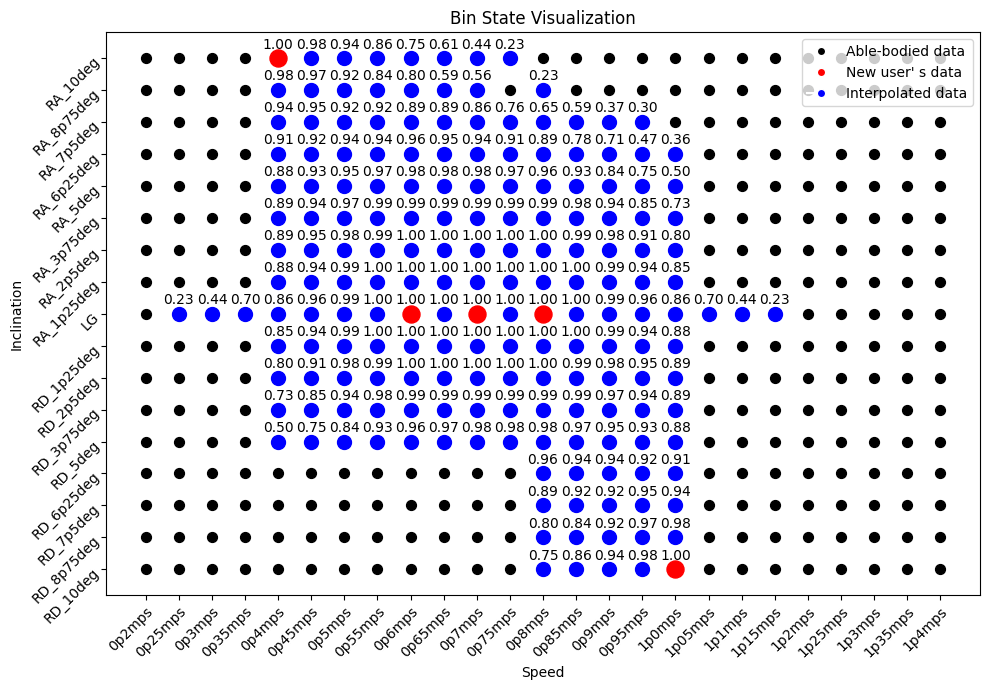

In [9]:
Online_Adaptator.bin_state

import numpy as np
import matplotlib.pyplot as plt

# Prepare data for the 2D plot
bin_state_values = np.zeros((len(Online_Adaptator.speeds_all), len(Online_Adaptator.inclinations_all)))

fig, ax = plt.subplots(figsize=(10, 7))

# Iterate through the bin_state dictionary and extract values for the first gait cycle
for i, inclination in enumerate(Online_Adaptator.inclinations_all):
    for j, speed in enumerate(Online_Adaptator.speeds_all):

        bin_state_value = Online_Adaptator.bin_state[inclination][speed]
        if bin_state_value is None:
            continue
        if bin_state_value == 0:
            ax.scatter(j, i, color='black', marker='o', s=50)  # Mark False values with gray circles
        elif bin_state_value == 1:
            ax.scatter(j, i, color='red', marker='o', s=150)  # Mark True values with white circles
            ax.text(j, i+0.2, f'{bin_state_value:.2f}', ha='center', va='bottom')
        elif bin_state_value < 1:
            ax.scatter(j, i, color='blue', marker='o', s=100)  # Mark True values with white circles
            ax.text(j, i+0.2, f'{bin_state_value:.2f}', ha='center', va='bottom')
            
# Set labels and title
ax.set_yticks(np.arange(len(Online_Adaptator.inclinations_all)))
ax.set_xticks(np.arange(len(Online_Adaptator.speeds_all)))
ax.set_yticklabels(Online_Adaptator.inclinations_all)
ax.set_xticklabels(Online_Adaptator.speeds_all)
plt.setp(ax.get_yticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

ax.set_title('Bin State Visualization')
ax.set_ylabel('Inclination')
ax.set_xlabel('Speed')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color = 'w', label='Able-bodied data', markerfacecolor='black',),
    plt.Line2D([0], [0], marker='o', color = 'w', label='New user\' s data', markerfacecolor='red',),
    plt.Line2D([0], [0], marker='o', color = 'w', label='Interpolated data', markerfacecolor='blue',)
]
ax.legend(handles=legend_elements, loc='upper right')

fig.tight_layout()
plt.show()

In [ ]:
from plotly.offline import iplot
import plotly.graph_objects as go

color_map = plt.get_cmap('tab20')
color_map.colors = list(color_map.colors)
color_map.colors.extend(color_map.colors[:5])
fig = go.Figure()

inclination = 'LG'
ch_idx = 7 # mtr_pos_L
for speed in speeds_all:
    if inclination != 'LG' and speed not in ['0p4mps', '0p6mps', '0p8mps', '1p0mps']:
        continue
    if inclination == 'RD_10deg' and speed in ['0p4mps', '0p6mps']:
        continue

    color = f"rgba{tuple(int(c*255) for c in color_map.colors[speeds_all.index(speed)]) + (1,)}"
    z = speeds_all.index(speed) 

    gait_cycle = 0
    fig.add_trace(go.Scatter3d(
        x=np.arange(len(avg_input_gait_cycles[inclination][speed][gait_cycle][ch_idx-1])),
        y=avg_input_gait_cycles[inclination][speed][gait_cycle][ch_idx-1],  # Use index 1 for motor position
        z=[z] * len(avg_input_gait_cycles[inclination][speed][gait_cycle][ch_idx-1]),  # Create a z-coordinate for each point
        mode='lines',
        line=dict(color=color),   # <-- use line.color instead of marker
        name = speed + ' - gait cycle ' + str(gait_cycle + 1),
    ))
fig.update_layout(title=f'Average Gait Cycles - {inclination} - {sensing_ch[ch_idx-1]}')

fig.update_layout(
    scene=dict(
        xaxis_title='Time (s/100)',        yaxis_title='Sensor signal value',        zaxis_title='Gait cycle index',
    ),
    width=1250,
    height=750,
)
iplot(fig)